In [53]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [54]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [55]:
catalog.search(collection='noc-npd-era5', item_name='tn')



            * Item ID: noc-npd-era5/npd-eorca1-era5v1/tn/M1m/MOVE_16N
              Title: eORCA1 ERA5v1 NPD M1m/MOVE_16N Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD ocean physics transect monthly mean outputs defined at MOVE_16N.
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/tn/M1m/SAMBA_34_5S
              Title: eORCA1 ERA5v1 NPD M1m/SAMBA_34_5S Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean scalar monthly mean outputs.
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/tn/M1m/RAPID_26N
              Title: eORCA1 ERA5v1 NPD M1m/RAPID_26N Icechunk repository
              Description: Icechunk repo

In [64]:
ds1 = catalog.open_dataset(id=catalog.Items[11].id, start_datetime='1990-01', end_datetime='2024-12')

In [63]:
ds1

<xarray.Dataset> Size: 1GB
Dimensions:           (bdy: 834, time_counter: 420, k: 75, sigma0_bins: 899)
Coordinates:
  * bdy               (bdy) int64 7kB 0 1 2 3 4 5 6 ... 828 829 830 831 832 833
  * time_counter      (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:00 ....
  * k                 (k) float32 300B 1.506 2.556 3.668 ... 5.699e+03 5.903e+03
  * sigma0_bins       (sigma0_bins) float64 7kB 20.01 20.02 ... 28.98 28.99
    depthb            (k, bdy) float64 500kB dask.array<chunksize=(75, 834), meta=np.ndarray>
    glamb             (bdy) float64 7kB dask.array<chunksize=(834,), meta=np.ndarray>
    gphib             (bdy) float64 7kB dask.array<chunksize=(834,), meta=np.ndarray>
Data variables: (12/14)
    e1b               (bdy) float64 7kB dask.array<chunksize=(834,), meta=np.ndarray>
    j_bdy             (bdy) float64 7kB dask.array<chunksize=(834,), meta=np.ndarray>
    flux_dir          (bdy) int64 7kB dask.array<chunksize=(834,), meta=np.ndarray>
    i_bdy             (bdy) float64 7kB dask.array<chunksize=(834,), meta=np.ndarray>
    flux_type         (bdy) <U1 3kB dask.array<chunksize=(834,), meta=np.ndarray>
    e3b               (time_counter, k, bdy) float64 210MB dask.array<chunksize=(1, 75, 834), meta=np.ndarray>
    ...                ...
    moc_west          (time_counter, sigma0_bins) float64 3MB dask.array<chunksize=(1, 899), meta=np.ndarray>
    sigma0            (time_counter, k, bdy) float64 210MB dask.array<chunksize=(1, 75, 834), meta=np.ndarray>
    so_abs            (time_counter, k, bdy) float64 210MB dask.array<chunksize=(1, 75, 834), meta=np.ndarray>
    thetao_con        (time_counter, k, bdy) float64 210MB dask.array<chunksize=(1, 75, 834), meta=np.ndarray>
    velocity          (time_counter, k, bdy) float64 210MB dask.array<chunksize=(1, 75, 834), meta=np.ndarray>
    volume_transport  (time_counter, k, bdy) float64 210MB dask.array<chunksize=(1, 75, 834), meta=np.ndarray>
Attributes:
    history:  Tue Dec  2 15:51:58 2025: ncrcat eORCA12_ERA5_v1_OSNAP_1976-01-...
    NCO:      netCDF Operators version 5.3.3 (Homepage = http://nco.sf.net, C...

In [72]:
ds1['moc_total'] = ds1['moc_total'] * 1e-6

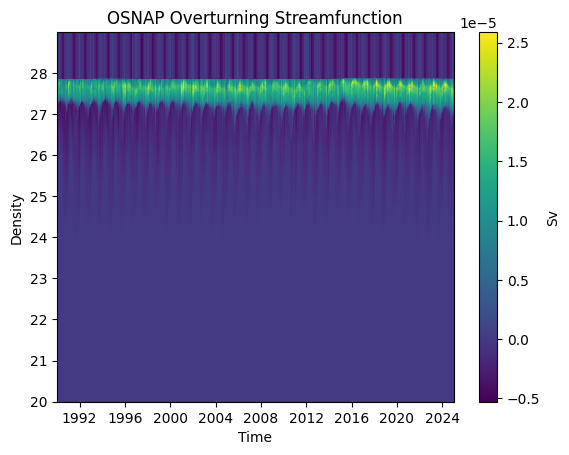

In [73]:
fig, ax = plt.subplots()

moc = ds1['moc_total']
pcm = ax.pcolormesh(moc['time_counter'], moc['sigma0_bins'], moc.T, shading='auto')
ax.set_xlabel('Time')
ax.set_ylabel('Density')
ax.set_title("OSNAP Overturning Streamfunction")
plt.colorbar(pcm, ax=ax, label='Sv')
# ax.set_xlim(np.datetime64('1990-01-01'), np.datetime64('2024-12-31'))
# ax.set_ylim(26,28)

In [67]:
# Summer only

moc_july = ds1['moc_total'].where(ds1['time_counter'].dt.month == 7, drop = True)


(26.0, 28.0)

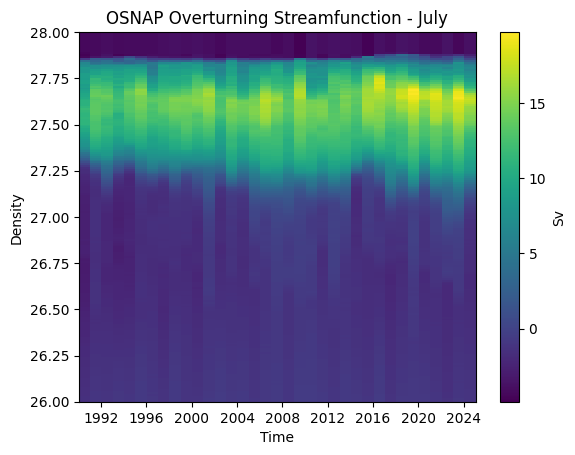

In [74]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(moc_july['time_counter'], moc_july['sigma0_bins'], moc_july.T, shading='auto')
ax.set_xlabel('Time')
ax.set_ylabel('Density')
ax.set_title("OSNAP Overturning Streamfunction - July")
plt.colorbar(pcm, ax=ax, label='Sv')
ax.set_ylim(26,28)

In [75]:
max_sf = moc.max(dim = 'sigma0_bins')

Text(0, 0.5, 'Maximum Overturning Streamfunction (Sv)')

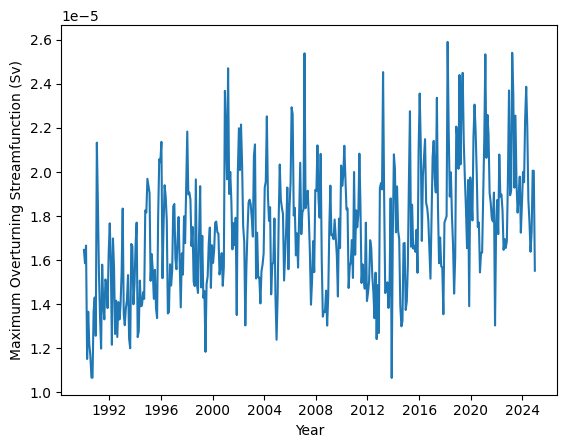

In [77]:
plt.plot(max_sf['time_counter'], max_sf)
plt.xlabel('Year')
plt.ylabel('Maximum Overturning Streamfunction (Sv)')

Text(0, 0.5, 'Maximum Overturning Streamfunction (Sv) - Annual Mean')

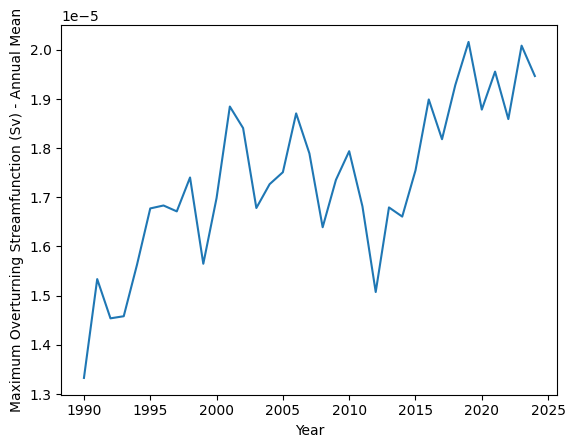

In [78]:
annual_mean = max_sf.groupby('time_counter.year').mean()
plt.plot(annual_mean['year'], annual_mean)
plt.xlabel('Year')
plt.ylabel('Maximum Overturning Streamfunction (Sv) - Annual Mean')